In [1]:
#Import needed libraries
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

In [2]:
#Split the training and testing data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [3]:
#Normalize the pixel values from [0, 255] to [0, 1] for improved CNN training performance
X_train = X_train / 255.0
X_test = X_test / 255.0
#Reshape the flattened image data into 28x28 format with 1 channel for the CNN input
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [4]:
#Build and define the CNN
fashion_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation="softmax")
])

In [5]:
#Compile the model
fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:

predictions = fashion_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [7]:
#Generate the confusion matrix
confusion_matrix = confusion_matrix(y_test, predicted_labels)
print(confusion_matrix)

[[ 11  32  24   0  12 433   0 477  11   0]
 [ 41   3   0   0 840  52   0  64   0   0]
 [ 13  55   3   0   3 843   6  31  46   0]
 [178   2  16   0 129 357   0 318   0   0]
 [  6  36   6   0  20 900   0  26   6   0]
 [183  69  51   1   1 177   3  42 473   0]
 [  8  69   2   0   6 771   5 124  15   0]
 [306   4  20   0   1  41   0   0 627   1]
 [370 216  13   0   5 202   6  92  96   0]
 [455  81   5   2   2 156   0 186 113   0]]


In [8]:
#Find the images that are misclassified
misclassified = np.where(predicted_labels != y_test)[0]

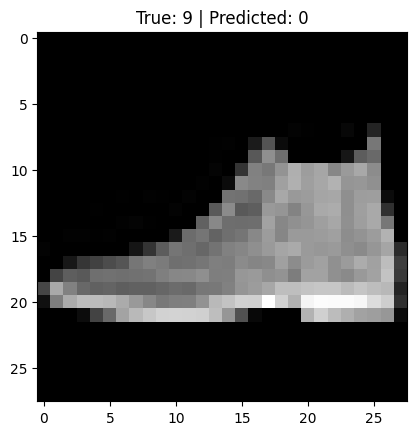

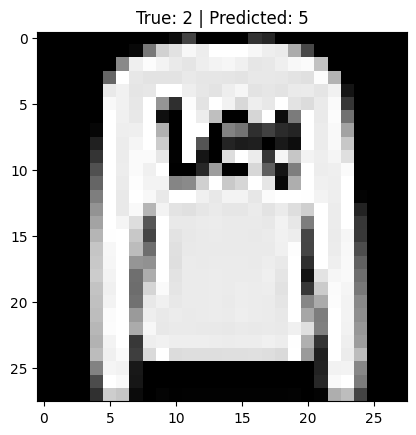

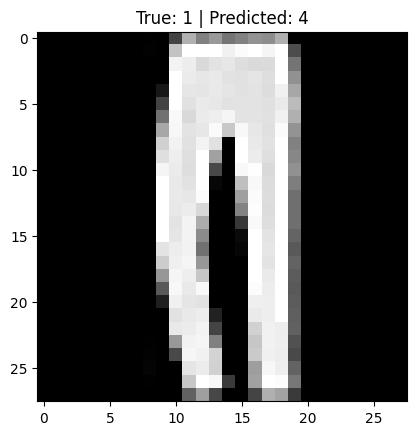

In [9]:
#Display three misclassified images
for i in range(3):
    index = misclassified[i]

    plt.imshow(X_test[index].reshape(28,28), cmap="gray")
    plt.title(f"True: {y_test[index]} | Predicted: {predicted_labels[index]}")
    plt.show()

In [10]:
"""
One pattern observed is that visually similar clothing items such as shirts and
t-shirts are frequently confused by the CNN.

One realistic improvement method would be increasing model complexity or training
for more epochs so the CNN can learn more detailed image features.
"""

'\nOne pattern observed is that visually similar clothing items such as shirts and\nt-shirts are frequently confused by the CNN.\n\nOne realistic improvement method would be increasing model complexity or training\nfor more epochs so the CNN can learn more detailed image features.\n'